# Model Training

- import dependencies data 
- Data Preprocessing & Feature Engineering 
- Dataset Split
- Model Training
- Model Evaluation

## 1 Import Data and Dependencies

### 1. 1 Import data and required packages

- importing Pandas, Numpy, Matplotlib, Seaborn and library and require models

In [ ]:
# Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

Import the CSV Data as pandas dataframe

In [26]:
filename = r'./data/stud.csv'
df = pd.read_csv(filename)

Show top 5 records

In [27]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


###  1.2 optimize 


In [28]:
# memory optimization
import utils
import importlib
importlib.reload(utils)
from utils import Variables
vars = Variables(df)
vars.refresh()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race_ethnicity               1000 non-null   category
 2   parental_level_of_education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test_preparation_course      1000 non-null   category
 5   math_score                   1000 non-null   int8    
 6   reading_score                1000 non-null   int8    
 7   writing_score                1000 non-null   int8    
dtypes: category(5), int8(3)
memory usage: 8.7 KB


## 2 Data Preprocessing and Feature engineering

- add the average column to the dataset
- We predict average using demographic and preparation features only. We exclude other scores - math, reading and writing scores - from features to ensure the model predicts independently and avoid data leakage.
- creation new features from categorical data using interaction terms

In [30]:
def new_cat_feature(columns:list):
    """ Create new categorical features from columns. With a maximum combination of three columns"""

    if not columns:
        raise ValueError("Your column list is empty")

    for column in columns:
        if column not in vars.categorical_var and column not in vars.object_var:
            raise NameError("Columnn you want to combine does not exist in the dataframe or is not a categorical variables.")
    
    if len(columns) == 2:
        new_feature_name = columns[0] + "_" + columns[1]
        df[new_feature_name] = df[columns[0]].astype(str) + "_" + df[columns[1]].astype(str)
    elif len(columns) == 3:
        new_feature_name = columns[0] + "_" + columns[1] + "_" + columns[2]
        df[new_feature_name] = df[columns[0]].astype(str) + "_" + df[columns[1]].astype(str) + "_" + df[columns[2]].astype(str)
    else:
        raise ValueError("Number of columns to combine must not be greater than 3 or less than 2")
    
    return new_feature_name
    
    



- Exploratory data analysis shows that there is an intersection between parental level of education and gender
- Moreover, studies have also shown that this intersection exists

"Parental education significantly predicted parental expectation, parent-child activity and reading achievement... the process of how family SES relates to "
"reading achievement was not the same for [boys and girls]." — Frontiers in Psychology, "Gender Differences in How Family Income and Parental Education..."
[https://pmc.ncbi.nlm.nih.gov/articles/PMC5992380/].

- lunch and test preparation course also show somewhat interconnection



In [31]:
# feature1 = ['gender', 'race_ethnicity']
feature4 = ['gender', 'parental_level_of_education']

# feature7 = ['race_ethnicity', 'test_preparation_course']

feature8 = ['lunch', 'test_preparation_course']

features = [feature4, feature8]

# Average column
df['average'] = df[vars.numerical_var].sum(axis=1) / len(vars.numerical_var)

for feature in features:
    try: 
        new_feature = new_cat_feature(feature)
        print(f"{new_feature.title()} has successfully been added!")
    except Exception as e:
        print("An error occured", e)

Gender_Parental_Level_Of_Education has successfully been added!
Lunch_Test_Preparation_Course has successfully been added!


In [32]:
# Optimize memory
vars.refresh()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              1000 non-null   category
 1   race_ethnicity                      1000 non-null   category
 2   parental_level_of_education         1000 non-null   category
 3   lunch                               1000 non-null   category
 4   test_preparation_course             1000 non-null   category
 5   math_score                          1000 non-null   int8    
 6   reading_score                       1000 non-null   int8    
 7   writing_score                       1000 non-null   int8    
 8   average                             1000 non-null   float32 
 9   gender_parental_level_of_education  1000 non-null   object  
 10  lunch_test_preparation_course       1000 non-null   category
dtypes: category(6), float32(1), int

In [34]:
X = df.drop(columns=['math_score', 'average'])
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score,gender_parental_level_of_education,lunch_test_preparation_course
0,female,group B,bachelor's degree,standard,none,72,74,female_bachelor's degree,standard_none
1,female,group C,some college,standard,completed,90,88,female_some college,standard_completed
2,female,group B,master's degree,standard,none,95,93,female_master's degree,standard_none
3,male,group A,associate's degree,free/reduced,none,57,44,male_associate's degree,free/reduced_none
4,male,group C,some college,standard,none,78,75,male_some college,standard_none


In [35]:
X.shape

(1000, 9)

In [36]:
print(vars.categorical_var)
X.info()

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              1000 non-null   category
 1   race_ethnicity                      1000 non-null   category
 2   parental_level_of_education         1000 non-null   category
 3   lunch                               1000 non-null   category
 4   test_preparation_course             1000 non-null   category
 5   reading_score                       1000 non-null   int8    
 6   writing_score                       1000 non-null   int8    
 7   gender_parental_level_of_education  1000 non-null   object  
 8   lunch_test_preparation_course       1000 non-null   category
dtypes: category(6), int8(2), object(1)
memory usage: 16.7+ KB


In [37]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int8

In [38]:
# Create Column Transformer with 3 types of transformers
X_vars = Variables(X)
X_vars.refresh()
cat_features = X_vars.categorical_var
num_features = X_vars.numerical_var
obj_features = X_vars.object_var

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_transformer = OneHotEncoder()
num_transformer = StandardScaler()

cat_features = cat_features + obj_features

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", cat_transformer, cat_features),
        ("StandardEncoder", num_transformer, num_features), 
    ]
)

In [39]:
X = preprocessor.fit_transform(X)

In [40]:
print(X[:])

  (0, 0)	1.0
  (0, 3)	1.0
  (0, 8)	1.0
  (0, 14)	1.0
  (0, 16)	1.0
  (0, 20)	1.0
  (0, 22)	1.0
  (0, 33)	0.19399858403803502
  (0, 34)	0.3914918076496706
  (1, 0)	1.0
  (1, 4)	1.0
  (1, 11)	1.0
  (1, 14)	1.0
  (1, 15)	1.0
  (1, 19)	1.0
  (1, 25)	1.0
  (1, 33)	1.4274759816659497
  (1, 34)	1.3132686840532009
  (2, 0)	1.0
  (2, 3)	1.0
  (2, 10)	1.0
  (2, 14)	1.0
  (2, 16)	1.0
  (2, 20)	1.0
  (2, 24)	1.0
  :	:
  (997, 9)	1.0
  (997, 13)	1.0
  (997, 15)	1.0
  (997, 17)	1.0
  (997, 23)	1.0
  (997, 33)	0.1254720619475953
  (997, 34)	-0.2010790414668845
  (998, 0)	1.0
  (998, 5)	1.0
  (998, 11)	1.0
  (998, 14)	1.0
  (998, 15)	1.0
  (998, 19)	1.0
  (998, 25)	1.0
  (998, 33)	0.6051577165806732
  (998, 34)	0.5890154240218557
  (999, 0)	1.0
  (999, 5)	1.0
  (999, 11)	1.0
  (999, 13)	1.0
  (999, 16)	1.0
  (999, 18)	1.0
  (999, 25)	1.0
  (999, 33)	1.153369893304191
  (999, 34)	1.1815862731384108


In [41]:
print(y)

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int8


### Training data
How Training data looks like

In [42]:
X_dense = X.toarray()

# Get OneHotEncoder columns
ohe_columns = preprocessor.named_transformers_['OneHotEncoder'].get_feature_names_out(cat_features)
columns_name = []
columns_name.extend(ohe_columns)
columns_name.extend(num_features)
print(columns_name)
print(len(columns_name))
excel_file = r'./training_data.xlsx'
save_df = pd.DataFrame(X_dense, columns=columns_name)
save_df['target'] = y
save_df.to_excel(excel_file, index=False)
print(f"Saved Training data to {excel_file}")

['gender_female', 'gender_male', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_associate's degree", "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school', 'lunch_free/reduced', 'lunch_standard', 'test_preparation_course_completed', 'test_preparation_course_none', 'lunch_test_preparation_course_free/reduced_completed', 'lunch_test_preparation_course_free/reduced_none', 'lunch_test_preparation_course_standard_completed', 'lunch_test_preparation_course_standard_none', "gender_parental_level_of_education_female_associate's degree", "gender_parental_level_of_education_female_bachelor's degree", 'gender_parental_level_of_education_female_high school', "gender_parental_level_of_education_female_master's degre

## 3 Dataset Split

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 35), (200, 35))

## 4. Model Training and Evaluation

- Create an Evaluate Function to give all metrics after model training

In [44]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [45]:

models = {
    "Linear Regression": LinearRegression(), 
    "Lasso": Lasso(),
    "Ridge": Ridge(), 
    "KN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "naive bayes": GaussianNB()
}

model_list = []

error_results = {}
train_mae_list = []
test_mae_list = []
train_rmse_list = []
test_rmse_list = []
train_r2_list = []
test_r2_list = []
y_train_acc = []
y_test_acc = []

for model_name, model in models.items():
    
    print(f"Training {model_name}")
    print("-" * 40)

    if model_name == "naive bayes":
        print("Naive Bayes needs a dense data set not a sparse one. Now converting sparse dataset to a dense dataset.")
        X_train = X_train.toarray()
        X_test = X_test.toarray()

    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_predict = model.predict(X_train)
    y_test_predict = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_predict)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_predict)

    model_list.append(model_name)
    train_mae_list.append(model_train_mae)
    test_mae_list.append(model_test_mae)
    train_rmse_list.append(model_train_rmse)
    test_rmse_list.append(model_test_rmse)
    train_r2_list.append(model_train_r2)
    test_r2_list.append(model_test_r2)
    
    print("-" * 40)

error_results["model"] = model_list
error_results["train_mae"] = train_mae_list
error_results["test_mae"] = test_mae_list
error_results["train_rmse"] = train_rmse_list
error_results["test_rmse"] = test_rmse_list
error_results["train_r2"] = train_r2_list
error_results["test_r2"] = test_r2_list

print("=" * 40) 
print("Done Training all models.")

Training Linear Regression
----------------------------------------
----------------------------------------
Training Lasso
----------------------------------------
----------------------------------------
Training Ridge
----------------------------------------
----------------------------------------
Training KN Regressor
----------------------------------------
----------------------------------------
Training Decision Tree Regressor
----------------------------------------
----------------------------------------
Training Random Forest Regressor
----------------------------------------
----------------------------------------
Training XGB Regressor
----------------------------------------
----------------------------------------
Training CatBoosting Regressor
----------------------------------------
----------------------------------------
Training AdaBoost Regressor
----------------------------------------
----------------------------------------
Training naive bayes
--------------

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5936\3200639709.py:4: RuntimeWarning: invalid value encountered in sqrt
  rmse = np.sqrt(mse)


In [46]:
results_df = pd.DataFrame(error_results)

In [47]:
results_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Linear Regression,4.261062,4.227151,5.318067,5.390586,0.874552,0.880584
1,Lasso,5.206303,5.157881,6.593816,6.519694,0.807146,0.825320
2,Ridge,4.259224,4.223563,5.318326,5.387857,0.874540,0.880705
3,KN Regressor,4.952250,6.189000,6.208345,7.890387,0.829035,0.744150
4,Decision Tree Regressor,0.018750,6.610000,0.279508,8.328265,0.999653,0.714965
5,Random Forest Regressor,1.843945,4.660254,2.302469,6.050577,0.976485,0.849553
6,XGB Regressor,0.609155,4.922286,0.893413,6.313508,0.996460,0.836194
7,CatBoosting Regressor,2.348893,4.715550,2.967779,6.104904,0.960932,0.846839
8,AdaBoost Regressor,4.756594,4.680455,5.767752,6.069902,0.852440,0.848591
9,naive bayes,18.181250,20.160000,1.711359,NaN,0.987009,1.009205


In [48]:
pd.DataFrame({"Model Name":model_list, "Test R2_Score":test_r2_list}).sort_values(by=["Test R2_Score"], ascending=False)

,Model Name,Test R2_Score
9,naive bayes,1.009205
2,Ridge,0.880705
0,Linear Regression,0.880584
5,Random Forest Regressor,0.849553
8,AdaBoost Regressor,0.848591
7,CatBoosting Regressor,0.846839
6,XGB Regressor,0.836194
1,Lasso,0.825320
3,KN Regressor,0.744150
4,Decision Tree Regressor,0.714965


### Linear Regression 

In [103]:
# lin_model = LinearRegression(n_jobs=-1)
# lin_model.fit(X_train, y_train)
# y_test_pred = lin_model.predict(X_test)
# y_train_pred = lin_model.predict(X_train)
# test_score = r2_score(y_test, y_test_pred) * 100
# train_score = r2_score(y_train, y_train_pred) * 100
# print(f"Accuracy of the model on test is {test_score:.2f}")
# print(f"Accuracy of the model on train is {train_score:.2f}")

lin_model = GaussianNB()
lin_model.fit(X_train, y_train)
y_test_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)
test_score = r2_score(y_test, y_test_pred) * 100
train_score = r2_score(y_train, y_train_pred) * 100
print(f"Accuracy of the model on test is {test_score:.2f}")
print(f"Accuracy of the model on train is {train_score:.2f}")

results = {'actual_train':y_test, 'predicted_train': y_test_pred, 'difference':y_test-y_test_pred} #  'actual test':y_test, 'predicted_test':y_test_pred
results_df = pd.DataFrame(results)

Accuracy of the model on test is 102.13
Accuracy of the model on train is 99.16


Text(0.5, 1.0, 'Training Scores')

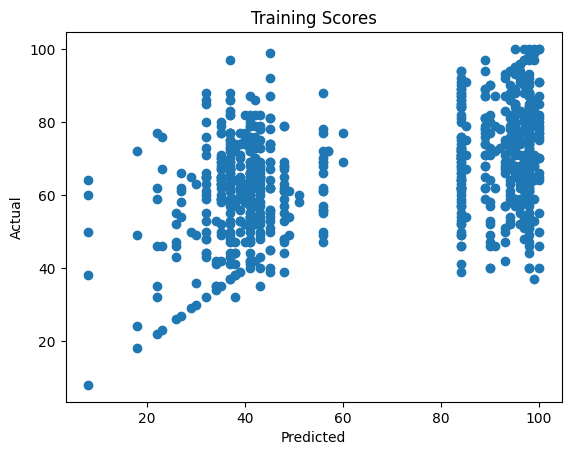

In [104]:
plt.scatter(y_train_pred, y_train)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Training Scores")

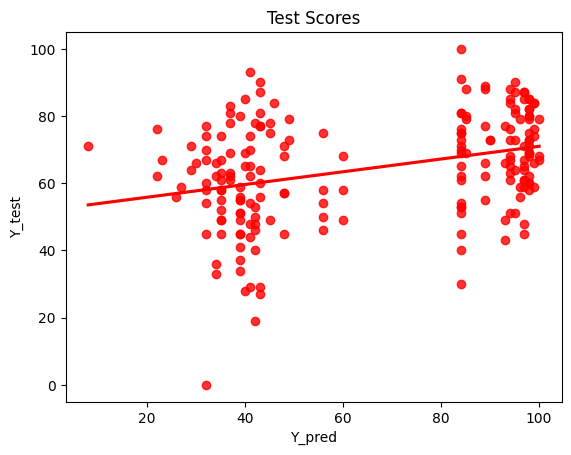

In [105]:
sns.regplot(x=y_test_pred, y=y_test, ci=None, color='red')
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.title('Test Scores')
plt.show()

In [106]:
results_df['difference'].max()

63

In [107]:
results_df['difference'].min()

-54